In [8]:
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import numpy as np
import os

# Load the pre-trained ResNet model
model = models.resnet18(pretrained=True)
model.eval()  # Set the model to evaluation mode

# Remove the final classification layer (fc) to extract features
model = torch.nn.Sequential(*list(model.children())[:-1])

# Define image transformation (same as during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Function to extract features
def extract_features(image_path):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    
    with torch.no_grad():
        features = model(image_tensor)  # Pass through pre-trained model to extract features
    
    # Convert features to a numpy array
    features = features.squeeze().cpu().numpy()  # Remove batch dimension and convert to numpy
    return features

# Function to extract features for all images in a directory
def extract_features_from_directory(directory_path):
    features_list = []
    
    # Loop through all image files in the directory
    for filename in os.listdir(directory_path):
        image_path = os.path.join(directory_path, filename)
        
        # Check if file is an image (e.g., with .jpg, .png extension)
        if image_path.endswith(('.jpg', '.jpeg', '.png')):
            features = extract_features(image_path)
            features_list.append(features)
    
    # Convert list of features to a numpy array (each row is a feature vector for an image)
    features_array = np.array(features_list)
    return features_array

# Example usage: Extract features from all images in a directory
image_directory = '../data/Leaf/train/Apple Apple Scab'  # Replace with your image directory
features_array = extract_features_from_directory(image_directory)

print("Extracted Features Shape:", features_array.shape)  # Should be (num_images, 512)

# Now you can use 'features_array' for further processing (e.g., SVM, PCA)


Extracted Features Shape: (0,)


c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Acer\.conda\envs\nlp-env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Features array shape: (33, 512)


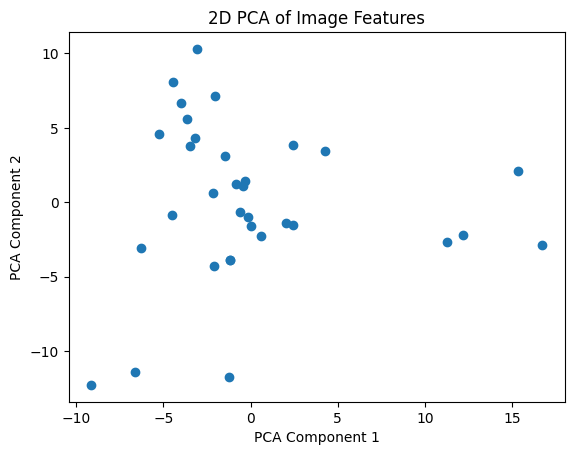

In [15]:
import os
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import numpy as np

# Load the pre-trained ResNet model
model = models.resnet18(pretrained=True)
model.eval()  # Set the model to evaluation mode

# Remove the final classification layer (fc) to extract features
model = torch.nn.Sequential(*list(model.children())[:-1])

# Define image transformation (same as during training)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Function to extract features
def extract_features(image_path):
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    
    with torch.no_grad():
        features = model(image_tensor)  # Pass through pre-trained model to extract features
    
    # Convert features to a numpy array
    features = features.squeeze().cpu().numpy()  # Remove batch dimension and convert to numpy
    return features

# Directory containing images
image_directory = '../data/Leaf/test'  # Replace with your directory path
features_list = []

# Loop through the directory and process each image
for image_filename in os.listdir(image_directory):
    image_path = os.path.join(image_directory, image_filename)
    features = extract_features(image_path)
    features_list.append(features)

# Convert the list of feature vectors into a numpy array
features_array = np.array(features_list)

# Check the shape of the features array
print("Features array shape:", features_array.shape)  # Should be (512, 512)

# Apply PCA to reduce the features to 2D for visualization
if features_array.shape[0] > 1:  # Ensure there are multiple images
    from sklearn.decomposition import PCA
    import matplotlib.pyplot as plt

    pca = PCA(n_components=2)
    reduced_features = pca.fit_transform(features_array)

    # Plot the 2D features
    plt.scatter(reduced_features[:, 0], reduced_features[:, 1])
    plt.title("2D PCA of Image Features")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.show()
else:
    print("Error: Not enough images to perform PCA.")


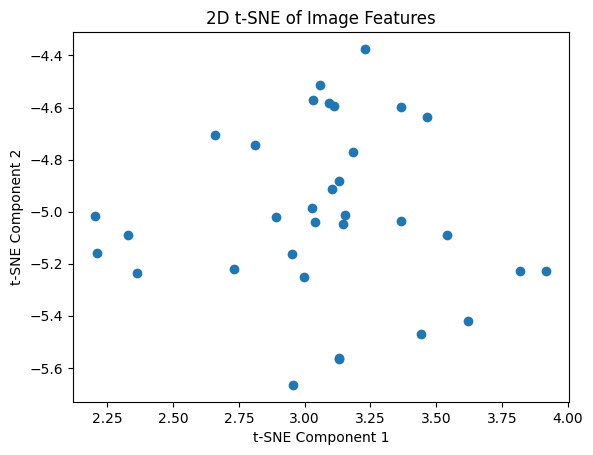

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Apply t-SNE to reduce the features to 2D for visualization
tsne = TSNE(n_components=2, random_state=42)
reduced_features_tsne = tsne.fit_transform(features_array)

# Plot the 2D features
plt.scatter(reduced_features_tsne[:, 0], reduced_features_tsne[:, 1])
plt.title("2D t-SNE of Image Features")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


In [12]:
print("Number of images processed:", len(features_array))


Number of images processed: 512
